<a href="https://colab.research.google.com/github/Navzz-afk/6thSem-ML-Lab/blob/main/Lab_9_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

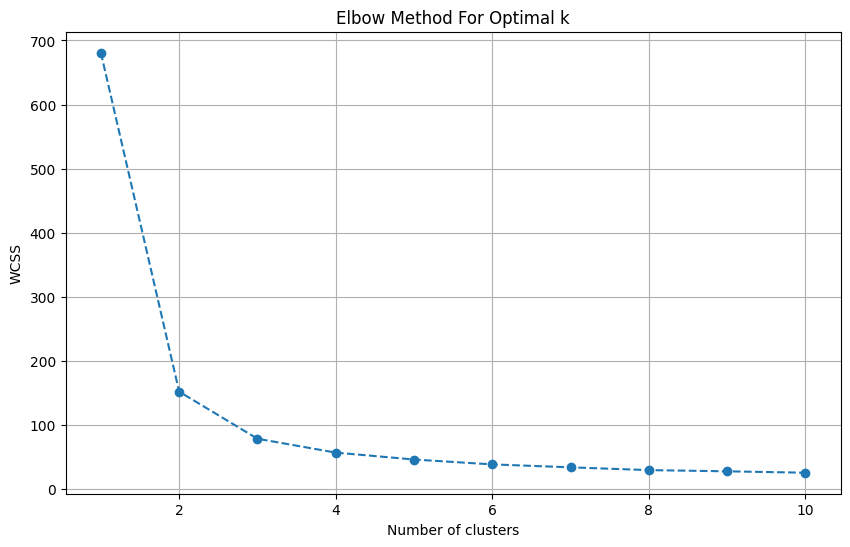

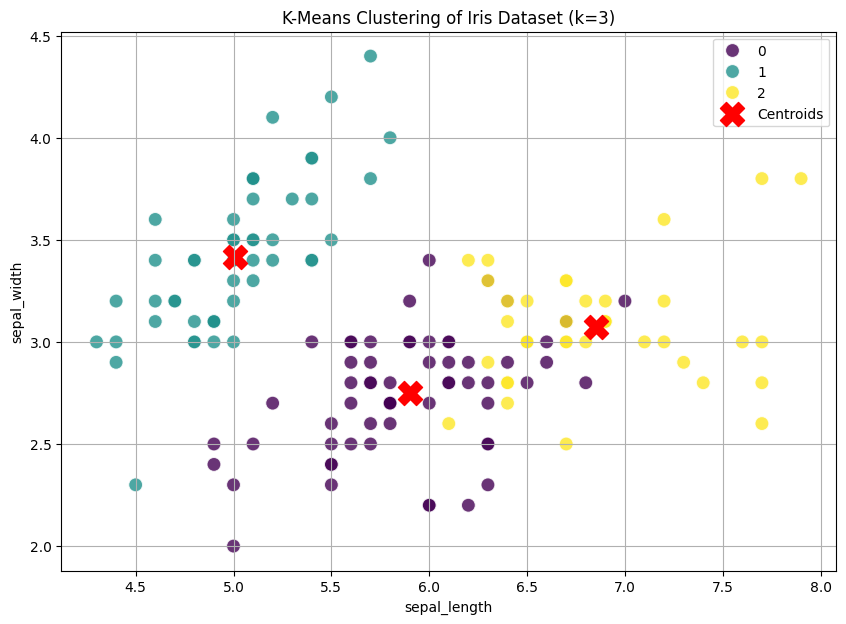

Cluster assignments:
cluster
0    62
1    50
2    38
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df = pd.read_csv('iris.csv')
except FileNotFoundError:
    print("Error: 'iris.csv' not found. Please upload the file or provide the correct path.")

feature_columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Check if original column names exist, if not, try common alternatives
if not all(col in df.columns for col in feature_columns):
    # If the standard scikit-learn names aren't present, try common CSV names
    feature_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
    if not all(col in df.columns for col in feature_columns):
        print("Warning: Could not find standard Iris feature columns. Using all numeric columns.")
        X = df.select_dtypes(include=['number']).copy()
    else:
        X = df[feature_columns].copy()
else:
    X = df[feature_columns].copy()


wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# From the elbow method or prior knowledge, we'll choose k=3 for Iris dataset
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Add the cluster labels to the original DataFrame (or the feature DataFrame)
X['cluster'] = y_kmeans

# Plotting the clusters based on two features
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X.columns[0], y=X.columns[1], hue='cluster', data=X, palette='viridis', s=100, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'K-Means Clustering of Iris Dataset (k={k})')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.legend()
plt.grid(True)
plt.show()

print("Cluster assignments:")
print(X['cluster'].value_counts())
